### Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os # os: for file and folder path handling

### Service Usage Analysis

#### Purpose of this notebook

This notebook analyses digital service usage patterns across age groups using the
`Life.xlsx` dataset from the Australian Digital Inclusion Index (ADII).

The main aim is to examine whether older Australians participate less in essential
online services compared to younger groups and the national average.

### Set paths

In [3]:
# Define project paths relative to the current notebook location.
# Current notebook location: src/notebooks
# We move one level up to src, then access:
# - data/raw_data
# - data/clean_data
# - outputs/charts

src_base_path = os.path.abspath(os.path.join(os.getcwd(), '..'))

data_path = os.path.join(src_base_path, 'data', 'raw_data')
clean_data_path = os.path.join(src_base_path, 'data', 'clean_data')
output_path = os.path.join(src_base_path, 'outputs', 'charts')

# Create clean_data and outputs/charts folders if they do not already exist.
os.makedirs(clean_data_path, exist_ok=True)
os.makedirs(output_path, exist_ok=True)

# Print paths to confirm that the notebook is reading and saving files correctly.
print("Current working directory:", os.getcwd())
print("src base path:", src_base_path)
print("Raw data path:", data_path)
print("Clean data path:", clean_data_path)
print("Output path:", output_path)

print("\nFiles in raw_data folder:")
print(os.listdir(data_path))

Current working directory: C:\Monash\SEM4\FIT-5120-main\FIT-5120-Main-project\src\notebooks
src base path: C:\Monash\SEM4\FIT-5120-main\FIT-5120-Main-project\src
Raw data path: C:\Monash\SEM4\FIT-5120-main\FIT-5120-Main-project\src\data\raw_data
Clean data path: C:\Monash\SEM4\FIT-5120-main\FIT-5120-Main-project\src\data\clean_data
Output path: C:\Monash\SEM4\FIT-5120-main\FIT-5120-Main-project\src\outputs\charts

Files in raw_data folder:
['Access.xlsx', 'Affordability.xlsx', 'AI.xlsx', 'Digital.xlsx', 'Life.xlsx', 'National.xlsx']


### Check sheet names in Life.xlsx

In [4]:
# Build the full path to the Life.xlsx file stored in raw_data.
file_path = os.path.join(data_path, 'Life.xlsx')

# Load the Excel workbook structure and print the available sheet names.
excel_file = pd.ExcelFile(file_path)
print("Sheet names in Life.xlsx:")
print(excel_file.sheet_names)

Sheet names in Life.xlsx:
['Export']


###  Load raw data

In [5]:
# Load the raw "Export" sheet without assigning a header.
# This keeps the original Excel layout intact for inspection.
df_raw = pd.read_excel(file_path, sheet_name='Export', header=None)

print("Raw dataset loaded successfully.")
print("Shape of raw dataset:", df_raw.shape)

Raw dataset loaded successfully.
Shape of raw dataset: (92, 8)


In [5]:
df_raw.head(20)

,0,1,2,3,4,5,6,7
0,"Thomas, J., McCosker, A., Parkinson, S., Hegar...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,All figures are weighted to the Australian pop...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Internet use,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Filters: none,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,View by: Age,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Inspect likely service usage section

In [6]:
# Display a wider slice of rows where the service usage table is likely located.
# This helps confirm that the extracted values used later are taken from the
# correct section of the Excel sheet.
df_raw.iloc[20:40, 0:10]

,0,1,2,3,4,5,6,7
20,75+,0.414313,0.251187,0.310743,0.023758,NaN,NaN,NaN
21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22,Use of digital services,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,NaN,National average,18-34,35-44,45-54,55-64,65-74,75+
25,Learning or study,0.782419,0.917185,0.877967,0.803813,0.686054,0.57702,0.497714
26,Manage money,0.952846,0.984729,0.98327,0.98545,0.944684,0.897978,0.791469
27,Government service,0.920891,0.961837,0.96159,0.939378,0.920457,0.856213,0.729257
28,Health service,0.811478,0.868532,0.896415,0.82097,0.790076,0.72924,0.546158
29,Compared prices,0.922592,0.96011,0.96344,0.952904,0.90928,0.875101,0.721462


### Initial exploration

The `Life.xlsx` file contains multiple grouped summary tables rather than one clean dataset.

From the raw inspection, one useful section shows digital service usage by age group.
This section is relevant because the project focuses on helping older Australians
navigate essential services such as:

- government services
- health services
- online money management


### Create cleaned service usage table

In [7]:
# Create a cleaned working table for service usage by age group.
# These values are extracted from the relevant section of Life.xlsx after inspection.
# A separate clean table makes later analysis and charting easier to manage.

service_usage = pd.DataFrame({
    'Service': [
        'Government Service',
        'Health Service',
        'Manage Money',
        'Learning / Study',
        'Compare Prices',
        'Look for Work'
    ],
    'National': [0.9209, 0.8115, 0.9528, 0.7824, 0.9226, 0.4253],
    '18–34':   [0.9618, 0.8685, 0.9847, 0.9172, 0.9601, 0.6340],
    '55–64':   [0.9205, 0.7901, 0.9447, 0.6861, 0.9093, 0.2782],
    '65–74':   [0.8562, 0.7292, 0.8980, 0.5770, 0.8751, 0.0940],
    '75+':     [0.7293, 0.5462, 0.7915, 0.4977, 0.7215, 0.0199]
})

print("Cleaned service usage table:")
print(service_usage)

Cleaned service usage table:
              Service  National   18–34   55–64   65–74     75+
0  Government Service    0.9209  0.9618  0.9205  0.8562  0.7293
1      Health Service    0.8115  0.8685  0.7901  0.7292  0.5462
2        Manage Money    0.9528  0.9847  0.9447  0.8980  0.7915
3    Learning / Study    0.7824  0.9172  0.6861  0.5770  0.4977
4      Compare Prices    0.9226  0.9601  0.9093  0.8751  0.7215
5       Look for Work    0.4253  0.6340  0.2782  0.0940  0.0199


###  Save cleaned table to CSV

In [8]:
# Save the cleaned service usage table to the clean_data folder.
# This improves reproducibility and allows the cleaned table to be reused later
# by other notebooks, reports, or frontend development if needed.

service_usage_file_path = os.path.join(clean_data_path, 'service_usage.csv')

service_usage.to_csv(service_usage_file_path, index=False)

print("Cleaned service usage data saved successfully ✓")
print("File location:", service_usage_file_path)


Cleaned service usage data saved successfully ✓
File location: C:\Monash\SEM4\FIT-5120-main\FIT-5120-Main-project\src\data\clean_data\service_usage.csv


In [9]:
# Print summary statistics for the cleaned service usage table.
print("Summary statistics:")
print(service_usage.describe())

Summary statistics:
       National     18–34     55–64     65–74       75+
count  6.000000  6.000000  6.000000  6.000000  6.000000
mean   0.802583  0.887717  0.754817  0.671583  0.551017
std    0.196874  0.130954  0.253181  0.307452  0.284124
min    0.425300  0.634000  0.278200  0.094000  0.019900
25%    0.789675  0.880675  0.712100  0.615050  0.509825
50%    0.866200  0.938650  0.849700  0.792700  0.633850
75%    0.922175  0.961375  0.917700  0.870375  0.727350
max    0.952800  0.984700  0.944700  0.898000  0.791500


### Focus on Epic 1 most relevant services

In [10]:
# Filter the cleaned dataset to keep only the three most relevant service categories
# for Epic 1 of the project:
# - Government Service
# - Health Service
# - Manage Money

epic1_services = service_usage[
    service_usage['Service'].isin([
        'Government Service',
        'Health Service',
        'Manage Money'
    ])
].copy()

print("Epic 1 relevant services:")
print(epic1_services)

Epic 1 relevant services:
              Service  National   18–34   55–64   65–74     75+
0  Government Service    0.9209  0.9618  0.9205  0.8562  0.7293
1      Health Service    0.8115  0.8685  0.7901  0.7292  0.5462
2        Manage Money    0.9528  0.9847  0.9447  0.8980  0.7915


### Why focus on these services?

The project problem statement highlights digital challenges in areas such as:

- Medicare bookings
- Centrelink applications
- online banking

These map most closely to the following service categories:

- **Government Service**
- **Health Service**
- **Manage Money**

These categories are therefore the most important for evaluating whether older
Australians participate less in essential digital services.

###  Chart 1: Service usage by age group

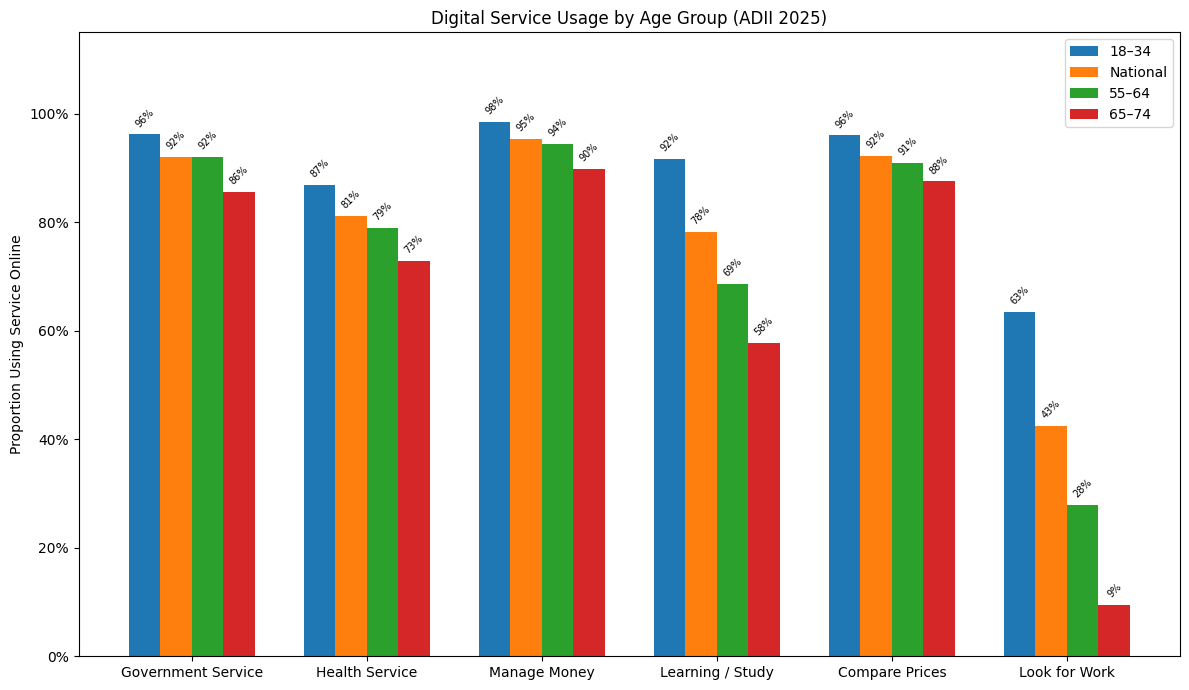

In [11]:
# Create a grouped bar chart comparing service usage across age groups.
# This chart provides a broad overview of how participation in digital services
# changes with age.

fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(service_usage))
width = 0.18

bars1 = ax.bar(x - width * 1.5, service_usage['18–34'], width, label='18–34')
bars2 = ax.bar(x - width * 0.5, service_usage['National'], width, label='National')
bars3 = ax.bar(x + width * 0.5, service_usage['55–64'], width, label='55–64')
bars4 = ax.bar(x + width * 1.5, service_usage['65–74'], width, label='65–74')

# Add percentage labels above each bar for easier interpretation.
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,
            f'{height:.0%}',
            ha='center',
            va='bottom',
            fontsize=7,
            rotation=45
        )

ax.set_xticks(x)
ax.set_xticklabels(service_usage['Service'])
ax.set_ylabel('Proportion Using Service Online')
ax.set_title('Digital Service Usage by Age Group (ADII 2025)')
ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend()

plt.tight_layout()

# Save the chart to the outputs/charts folder.
plt.savefig(os.path.join(output_path, 'service_usage_by_age.png'),
            dpi=150, bbox_inches='tight')
plt.show()

###  Calculate service usage gaps

To make the analysis more targeted, the next step is to compare older age groups
against the national average.

This helps quantify the participation gap and makes the findings easier to link
to the project's focus on essential services.

### Calculate usage gaps

In [12]:
# Calculate the usage gap between older age groups and the national average.
# Negative values indicate that the age group uses the service less than the
# overall Australian average.

service_usage['Gap_65_74'] = service_usage['65–74'] - service_usage['National']
service_usage['Gap_75+'] = service_usage['75+'] - service_usage['National']

print(service_usage[['Service', 'National', '65–74', '75+', 'Gap_65_74', 'Gap_75+']])

              Service  National   65–74     75+  Gap_65_74  Gap_75+
0  Government Service    0.9209  0.8562  0.7293    -0.0647  -0.1916
1      Health Service    0.8115  0.7292  0.5462    -0.0823  -0.2653
2        Manage Money    0.9528  0.8980  0.7915    -0.0548  -0.1613
3    Learning / Study    0.7824  0.5770  0.4977    -0.2054  -0.2847
4      Compare Prices    0.9226  0.8751  0.7215    -0.0475  -0.2011
5       Look for Work    0.4253  0.0940  0.0199    -0.3313  -0.4054


###  Focus on Epic 1 service gaps

In [13]:
# Re-filter the dataset to focus only on the three essential service categories
# most relevant to the project scope.

epic1_services = service_usage[
    service_usage['Service'].isin([
        'Government Service',
        'Health Service',
        'Manage Money'
    ])
].copy()

print("Epic 1 service gaps:")
print(epic1_services[['Service', 'National', '65–74', '75+', 'Gap_65_74', 'Gap_75+']])

Epic 1 service gaps:
              Service  National   65–74     75+  Gap_65_74  Gap_75+
0  Government Service    0.9209  0.8562  0.7293    -0.0647  -0.1916
1      Health Service    0.8115  0.7292  0.5462    -0.0823  -0.2653
2        Manage Money    0.9528  0.8980  0.7915    -0.0548  -0.1613


### Chart 2: Drop-off from national average

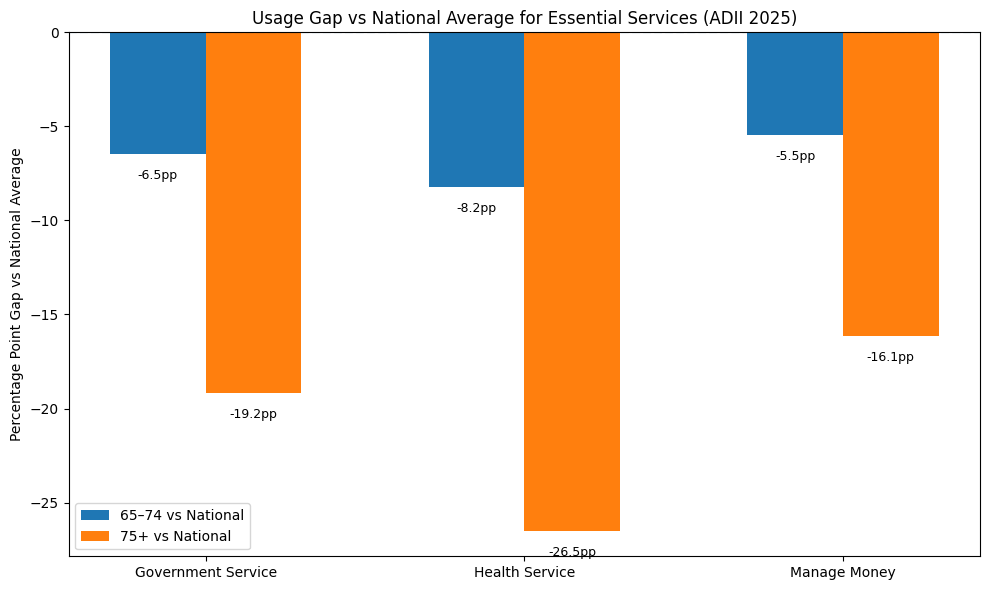

In [14]:
# Create a second chart showing the percentage-point gap relative to the national average.
# This makes it easier to identify which essential services have the largest drop-off
# for older adults.

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(epic1_services))
width = 0.3

bars1 = ax.bar(x - width / 2, epic1_services['Gap_65_74'] * 100, width,
               label='65–74 vs National')
bars2 = ax.bar(x + width / 2, epic1_services['Gap_75+'] * 100, width,
               label='75+ vs National')

# Add data labels to each bar.
for bars in [bars1, bars2]:
    for bar in bars:
        value = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value - 0.8 if value < 0 else value + 0.3,
            f'{value:.1f}pp',
            ha='center',
            va='top' if value < 0 else 'bottom',
            fontsize=9
        )

# Add a horizontal reference line at zero for easier comparison.
ax.axhline(y=0, linestyle='--')

ax.set_xticks(x)
ax.set_xticklabels(epic1_services['Service'])
ax.set_ylabel('Percentage Point Gap vs National Average')
ax.set_title('Usage Gap vs National Average for Essential Services (ADII 2025)')
ax.legend()

plt.tight_layout()

# Save the chart to the outputs/charts folder.
plt.savefig(os.path.join(output_path, 'service_usage_dropoff.png'),
            dpi=150, bbox_inches='tight')
plt.show()

### Rank biggest participation gaps

In [15]:
# Rank the essential services by the size of the participation gap for the
# 65–74 age group. More negative values indicate larger drop-offs.

ranked_gaps = epic1_services[['Service', 'Gap_65_74']].sort_values(by='Gap_65_74')

print("Largest participation gaps for age 65–74:")
print(ranked_gaps)

Largest participation gaps for age 65–74:
              Service  Gap_65_74
1      Health Service    -0.0823
0  Government Service    -0.0647
2        Manage Money    -0.0548


###  Key findings

### Digital service participation
The chart shows that service usage generally declines with age across all categories.

For the target audience:
- government service usage is lower than the national average
- health service usage is lower than the national average
- managing money online is also lower, although still relatively high

### Essential service gaps
Among the three essential services most relevant to the project:
- **Health Service** shows one of the clearest participation gaps
- **Government Service** also shows a meaningful gap
- **Manage Money** remains high, but still drops for older users

### Relevance to the project
These findings support:

- **Epic 1: Digital Services Directory**, because older adults may need clearer
  guidance on where and how to access essential online services
- **Epic 2: Step-by-Step How-To Guides**, because lower participation suggests
  that many users may need structured support to complete digital tasks confidently

Overall, the ADII data supports the need for a platform that improves access,
understanding, and confidence in using essential online services.

In [16]:
# Final verification step:
# - check saved chart files
# - check saved cleaned CSV files

print("Charts currently saved:")
print(os.listdir(output_path))

print("\nClean data files currently saved:")
print(os.listdir(clean_data_path))

Charts currently saved:
['barriers_by_age.png', 'digital_ability_by_age.png', 'digital_exclusion.png', 'service_usage_by_age.png', 'service_usage_dropoff.png']

Clean data files currently saved:
['access_connection.csv', 'access_devices.csv', 'access_frequency.csv', 'access_score.csv', 'access_time.csv', 'afford_10pct.csv', 'afford_compromised.csv', 'afford_sacrificed.csv', 'afford_score.csv', 'afford_subgroup.csv', 'barriers_by_age.csv', 'digital_ability_by_age.csv', 'digital_exclusion_by_age.csv', 'national_remoteness.csv', 'national_state.csv', 'national_time.csv', 'service_usage.csv']
